In [391]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import train_test_split, TimeSeriesSplit, cross_validate
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import(mean_absolute_error,mean_squared_error, r2_score)
from sklearn.base import BaseEstimator, TransformerMixin
import warnings
warnings.filterwarnings("ignore")

In [392]:
df=pd.read_csv("/content/train.csv")

In [393]:
df

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
10881,2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336
10882,2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241
10883,2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168
10884,2012-12-19 22:00:00,4,0,1,1,13.94,17.425,61,6.0032,12,117,129


In [394]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


In [395]:
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [396]:
df.describe()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
std,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454
min,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000
max,4.000000,1.000000,1.000000,4.000000,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000


In [397]:
df.describe(include="all")

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,10886,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
unique,10886,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,2012-12-19 23:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
std,NaN,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454
min,NaN,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,NaN,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,NaN,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,NaN,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000


In [398]:
df.shape

(10886, 12)

In [399]:
df.columns

Index(['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp',
       'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count'],
      dtype='object')

In [400]:
df.columns.tolist()


['datetime',
 'season',
 'holiday',
 'workingday',
 'weather',
 'temp',
 'atemp',
 'humidity',
 'windspeed',
 'casual',
 'registered',
 'count']

In [401]:
df.dtypes

,0
datetime,object
season,int64
holiday,int64
workingday,int64
weather,int64
temp,float64
atemp,float64
humidity,int64
windspeed,float64
casual,int64


In [402]:
df.isnull().sum()

,0
datetime,0
season,0
holiday,0
workingday,0
weather,0
temp,0
atemp,0
humidity,0
windspeed,0
casual,0


In [403]:
df.duplicated().sum()

np.int64(0)

In [404]:
df=df.drop_duplicates()
df

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
10881,2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336
10882,2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241
10883,2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168
10884,2012-12-19 22:00:00,4,0,1,1,13.94,17.425,61,6.0032,12,117,129


In [405]:
numeric_columns = [
    "temp",
    "atemp",
    "humidity",
    "windspeed",
    "count"
]


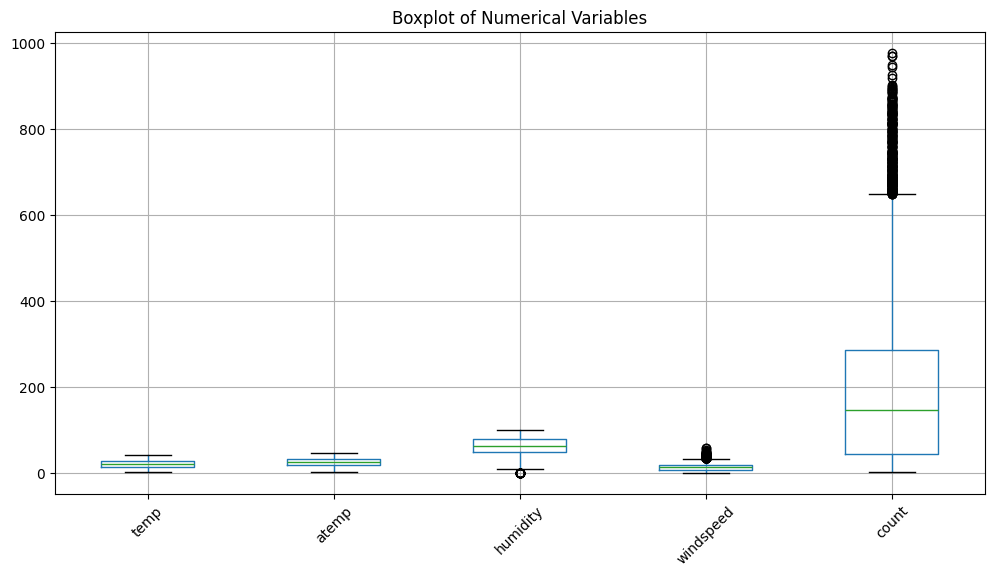

In [406]:
plt.figure(figsize=(12,6))
df[numeric_columns].boxplot()
plt.title("Boxplot of Numerical Variables")
plt.xticks(rotation=45)
plt.show()

Some hours have much higher rentals than usual, while temperature, humidity, and wind speed stay fairly stable.

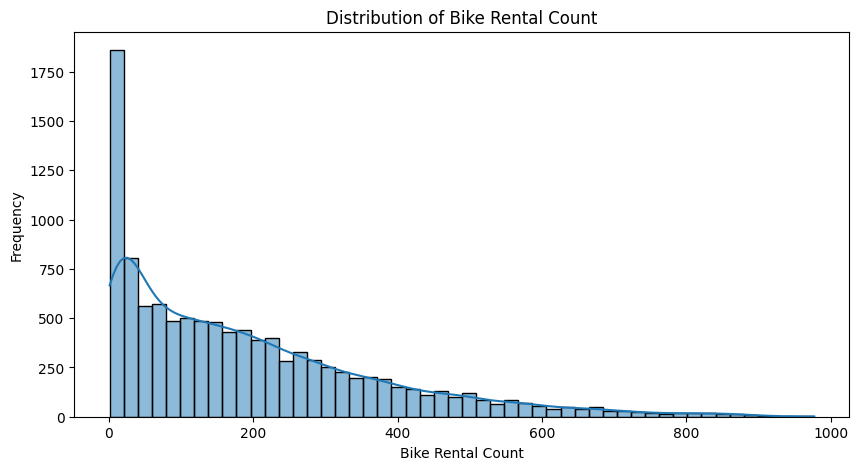

In [407]:
plt.figure(figsize=(10, 5))
sns.histplot(df["count"],bins=50,kde=True)
plt.title("Distribution of Bike Rental Count")
plt.xlabel("Bike Rental Count")
plt.ylabel("Frequency")
plt.show()

Most hours have a low number of rentals, while only a few hours have very high rentals.

In [408]:
df["datetime"] = pd.to_datetime(df["datetime"])

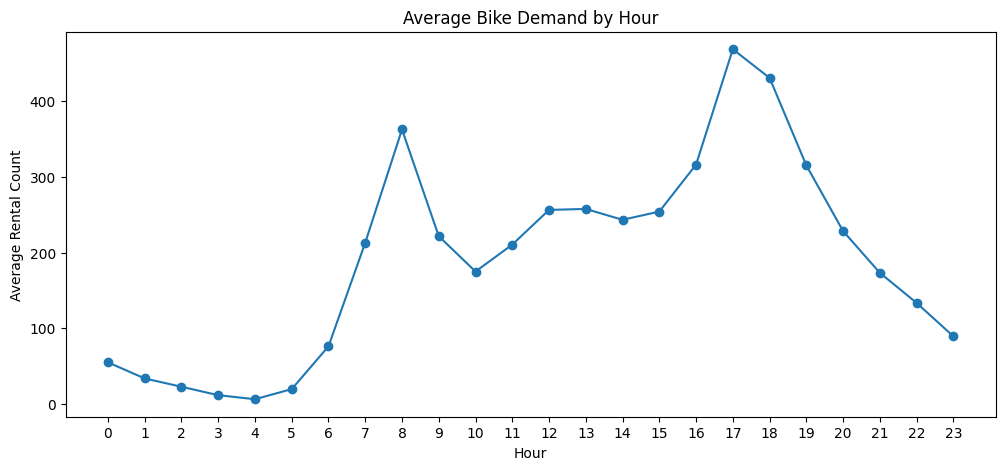

In [409]:
df["hour"] = df["datetime"].dt.hour
hourly_demand = df.groupby("hour")["count"].mean()
plt.figure(figsize=(12, 5))
hourly_demand.plot(marker="o")
plt.title("Average Bike Demand by Hour")
plt.xlabel("Hour")
plt.ylabel("Average Rental Count")
plt.xticks(range(24))
plt.show()

Bike rentals are highest around 8 AM and 5–6 PM, mainly because of work travel. Rentals are lowest around 3–4 AM.

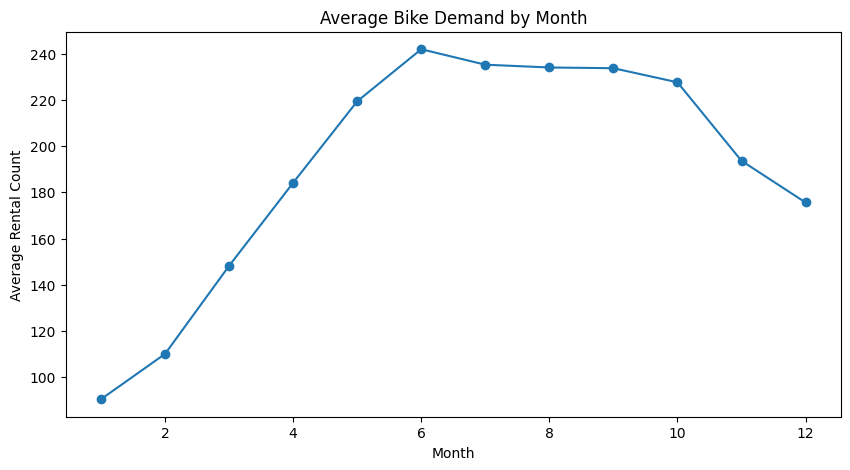

In [410]:
df["month"] = df["datetime"].dt.month
monthly_demand = df.groupby("month")["count"].mean()
plt.figure(figsize=(10, 5))
monthly_demand.plot(marker="o")
plt.title("Average Bike Demand by Month")
plt.xlabel("Month")
plt.ylabel("Average Rental Count")
plt.show()

Rentals rise from January, peak around June, stay high through September, then drop off toward December.

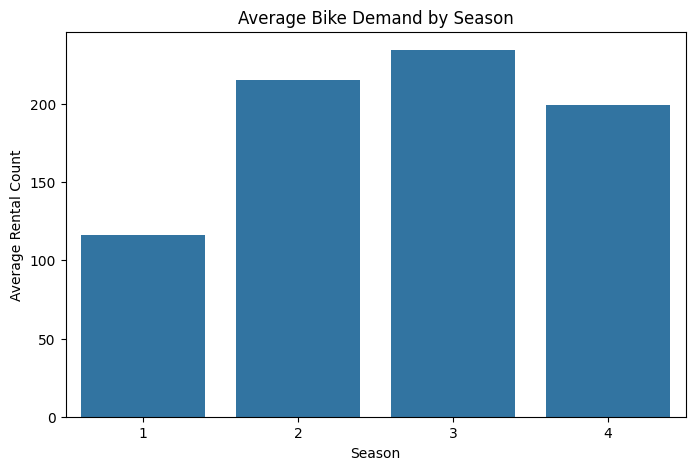

In [411]:
season_demand = df.groupby("season")["count"].mean()
plt.figure(figsize=(8, 5))
sns.barplot(x=season_demand.index,y=season_demand.values)
plt.title("Average Bike Demand by Season")
plt.xlabel("Season")
plt.ylabel("Average Rental Count")
plt.show()

Bike rentals are lowest in Season 1 and highest in Season 3. People rent more bikes during warmer seasons

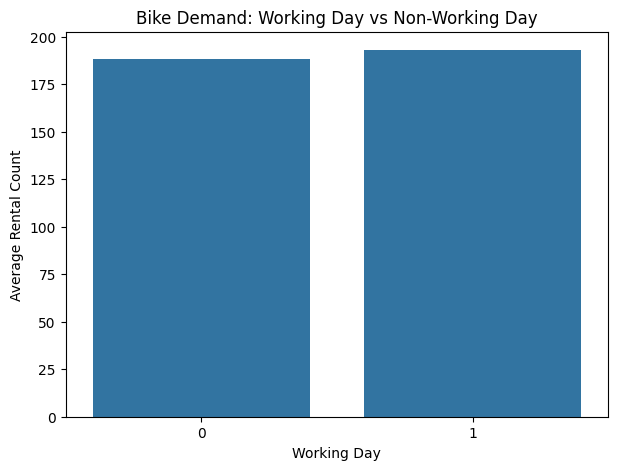

In [412]:
workingday_demand = df.groupby("workingday")["count"].mean()
plt.figure(figsize=(7, 5))
sns.barplot(x=workingday_demand.index,y=workingday_demand.values)
plt.title("Bike Demand: Working Day vs Non-Working Day")
plt.xlabel("Working Day")
plt.ylabel("Average Rental Count")
plt.show()

Bike rentals are almost the same on working and non-working days, so the day type has little effect on rentals.

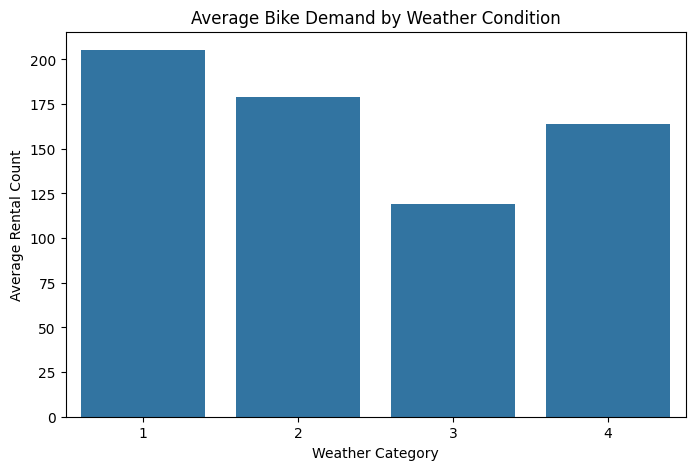

In [413]:
weather_demand = df.groupby("weather")["count"].mean()
plt.figure(figsize=(8, 5))
sns.barplot(x=weather_demand.index,y=weather_demand.values)
plt.title("Average Bike Demand by Weather Condition")
plt.xlabel("Weather Category")
plt.ylabel("Average Rental Count")
plt.show()

People rent the most bikes when the weather is clear and the least when it is rainy or snowy.

In [414]:
correlation_columns = [
    "temp",
    "atemp",
    "humidity",
    "windspeed",
    "count"
]

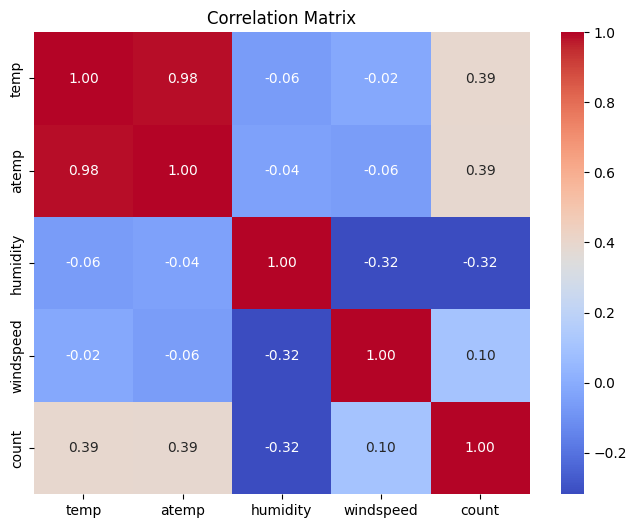

In [415]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[correlation_columns].corr(),annot=True,cmap="coolwarm",fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

When the weather is warmer, more people rent bikes. When humidity is high, fewer people rent bikes. Wind has very little effect on bike rentals

In [416]:
from sklearn.base import BaseEstimator, TransformerMixin


class BikeFeatureEngineer(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X["datetime"] = pd.to_datetime(X["datetime"])
        X["year"] = X["datetime"].dt.year
        X["month"] = X["datetime"].dt.month
        X["day"] = X["datetime"].dt.day
        X["hour"] = X["datetime"].dt.hour
        X["dayofweek"] = X["datetime"].dt.dayofweek
        X["is_weekend"] = (X["dayofweek"] >= 5).astype(int)
        X["is_rush_hour"] = (X["hour"].isin([7, 8, 9, 16, 17, 18, 19]) ).astype(int)
        X["is_peak_hour"] = (X["hour"].isin([8, 9, 17, 18]) ).astype(int)
        X = X.drop(columns=["datetime"])
        return X

This code takes the date and creates useful features like year, month, hour, weekend, and rush hour. This helps the model understand when bike demand is higher or lower.

In [417]:
target = "count"
features = [
    "datetime",
    "season",
    "holiday",
    "workingday",
    "weather",
    "temp",
    "atemp",
    "humidity",
    "windspeed"
]
X = df[features].copy()
y = df[target].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10886, 9)
y shape: (10886,)


In [418]:
split_index = int(len(X) * 0.80)
X_train = X.iloc[:split_index].copy()
X_test = X.iloc[split_index:].copy()
y_train = y.iloc[:split_index].copy()
y_test = y.iloc[split_index:].copy()

In [419]:
categorical_features = [
    "season",
    "holiday",
    "workingday",
    "weather"
]

In [420]:
numerical_features = [
    "temp",
    "atemp",
    "humidity",
    "windspeed",
    "year",
    "month",
    "day",
    "hour",
    "dayofweek",
    "is_weekend",
    "is_rush_hour",
    "is_peak_hour"
]


In [421]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numerical_features
        )
    ]
)

In [422]:
linear_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numerical",
            StandardScaler(),
            numerical_features
        )
    ]
)

In [423]:
linear_model = Pipeline(
    steps=[
        ("features", BikeFeatureEngineer()),
        ("preprocessor", linear_preprocessor),
        ("model", LinearRegression())
    ]
)

linear_model.fit(X_train,y_train)
linear_pred = linear_model.predict(X_test)

In [424]:
rf_model = Pipeline(
    steps=[
        ("features", BikeFeatureEngineer()),
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=300,
                max_depth=20,
                min_samples_split=2,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

rf_model.fit(X_train,y_train)
rf_pred = rf_model.predict(X_test)

In [425]:
def evaluate_model(name, y_true, predictions):

    mae = mean_absolute_error(y_true,predictions)
    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            predictions
        )
    )
    r2 = r2_score(y_true,predictions)

    return {
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }


In [426]:
results = []

results.append(
    evaluate_model(
        "Linear Regression",
        y_test,
        linear_pred
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        rf_pred
    )
)

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="RMSE")
display(results_df)

,Model,MAE,RMSE,R2
1,Random Forest,51.074591,78.487454,0.869895
0,Linear Regression,114.064193,150.713022,0.520271


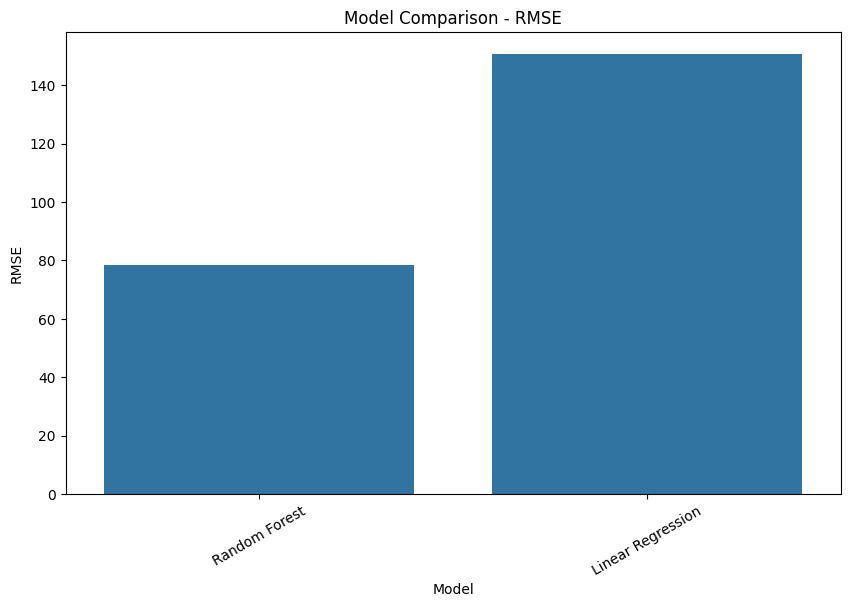

In [427]:
plt.figure(figsize=(10, 6))
sns.barplot(data=results_df,x="Model",y="RMSE")
plt.title("Model Comparison - RMSE")
plt.xticks(rotation=30)
plt.show()

Random Forest makes smaller mistakes than Linear Regression when predicting

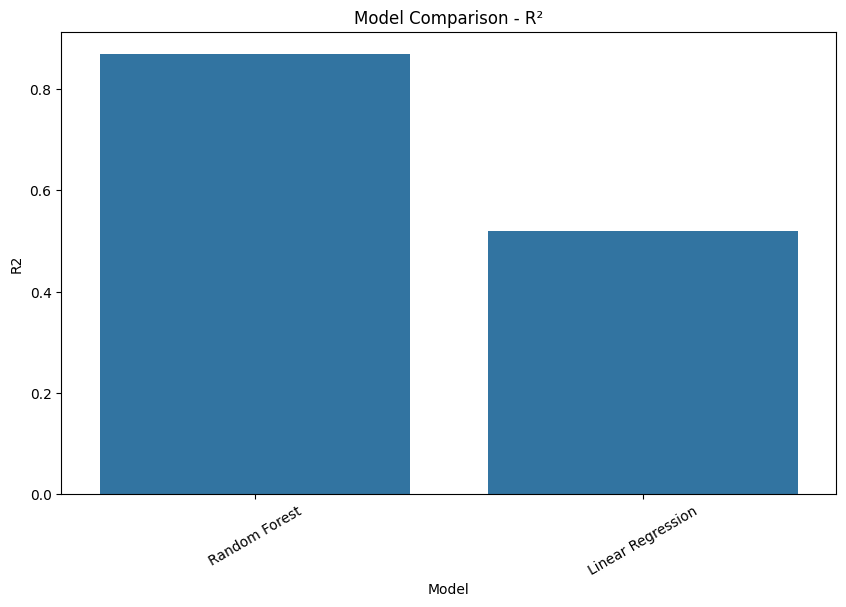

In [428]:
plt.figure(figsize=(10, 6))
sns.barplot(data=results_df,x="Model",y="R2")
plt.title("Model Comparison - R²")
plt.xticks(rotation=30)
plt.show()

Random Forest is way better at predicting than Linear Regression

In [429]:
tscv = TimeSeriesSplit(n_splits=5)

cv_results = []

for name, model in [
    ("Linear Regression", linear_model),
    ("Random Forest", rf_model)
]:

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=tscv,
        scoring={
            "MAE": "neg_mean_absolute_error",
            "RMSE": "neg_root_mean_squared_error",
            "R2": "r2"
        },
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "Validation MAE": -scores["test_MAE"].mean(),
        "Validation RMSE": -scores["test_RMSE"].mean(),
        "Validation R2": scores["test_R2"].mean()
    })

cv_results_df = pd.DataFrame(cv_results)
cv_results_df

,Model,Validation MAE,Validation RMSE,Validation R2
0,Linear Regression,89.982317,116.554878,0.485643
1,Random Forest,50.537068,76.287742,0.762860


In [430]:
test_results = []

test_results.append(
    evaluate_model("Linear Regression",y_test,linear_pred)
)

test_results.append(
    evaluate_model("Random Forest",y_test,rf_pred)
)

test_results_df = pd.DataFrame(test_results)

test_results_df

,Model,MAE,RMSE,R2
0,Linear Regression,114.064193,150.713022,0.520271
1,Random Forest,51.074591,78.487454,0.869895


The test results show that Random Forest performed better than Linear Regression.

In [431]:
final_model = rf_model
joblib.dump(final_model, "bike_demand_model.pkl")

print("Model saved successfully!")

Model saved successfully!


This code selects the Random Forest model as the final model and saves it as bike_demand_model.pkl.